In [83]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Classical models
import pmdarima as pm
from arch import arch_model

# Prophet
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet  # fallback for older envs

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# TimesFM
import timesfm

# import warnings
# warnings.filterwarnings("ignore")

TICKER = "AAPL"
START  = "2017-05-01"
END    = "2026-05-04"
TEST_SIZE = 252                 # roughly 1 trading year
LSTM_WINDOW = 30                # lookback window


In [85]:
# 2.1 Download daily data
raw = yf.download(TICKER, start=START, end=END)

# Use adjusted close if you prefer; here: Close
data = raw['Close'].asfreq('B')       # business days
data = data.ffill()                 # forward-fill missing days
data = np.log(data).diff().dropna() # log returns

# 2.2 Train / test split
train = data.iloc[:-TEST_SIZE].copy()
test  = data.iloc[-TEST_SIZE:].copy()

print(train.tail(), "\n\n", test.head())

C:\Users\admin\AppData\Local\Temp\ipykernel_29356\3973426608.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(TICKER, start=START, end=END)
[*********************100%***********************]  1 of 1 completed

Ticker          AAPL
Date                
2025-05-08  0.006299
2025-05-09  0.005252
2025-05-12  0.061233
2025-05-13  0.010101
2025-05-14 -0.002822 

 Ticker          AAPL
Date                
2025-05-15 -0.004153
2025-05-16 -0.000899
2025-05-19 -0.011809
2025-05-20 -0.009239
2025-05-21 -0.023329


In [87]:
def evaluate_forecast(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {"model": label, "rmse": rmse, "mae": mae}

results = []

In [89]:
def fit_predict_arima(train, test):
    y_train = train[TICKER].values
    model = pm.auto_arima(
        y_train,
        seasonal=False,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    preds = model.predict(n_periods=len(test))
    preds = pd.Series(preds, index=test.index, name="arima")
    return preds

arima_pred = fit_predict_arima(train, test)
results.append(evaluate_forecast(test[TICKER], arima_pred, "ARIMA"))

In [91]:
def fit_predict_garch(train, test):
    r = 100 * data[TICKER]
    train_r = r.loc[:train.index[-1]].copy()
    test_r = r.loc[test.index].dropna()
    H = len(test_r)
    assert H > 0, "No returns found for test window"

    am = arch_model(
        train_r,
        vol='Garch',
        p=1,
        q=1,
        mean='Constant',
        dist='normal',
        rescale=False
    )
    res = am.fit(disp='off')

    fc = res.forecast(horizon=H)
    last_row = fc.mean.iloc[-1]
    mean_fc = pd.Series(last_row.values, index=test_r.index, name="garch_r")

    return test_r, mean_fc

def garch_returns_to_prices(last_train_price, pred_returns_pct):
    r_dec = pred_returns_pct / 100.0

    prices = [last_train_price]
    for r in r_dec:
        prices.append(prices[-1] * np.exp(r))

    prices = pd.Series(prices[1:], index=pred_returns_pct.index, name="garch_price")
    return prices

last_train_price = train[TICKER].iloc[-1]
garch_true_r, garch_pred_r = fit_predict_garch(train, test)
garch_price_pred = garch_returns_to_prices(last_train_price, garch_pred_r)

results.append(
    evaluate_forecast(test[TICKER], garch_price_pred, "GARCH (price)")
)

In [93]:
results

[{'model': 'ARIMA', 'rmse': 0.013874127919460758, 'mae': 0.009752990279988575},
 {'model': 'GARCH (price)',
  'rmse': 0.01459935371912229,
  'mae': 0.010452728517151717}]

In [95]:
def create_lstm_sequences(arr, window):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, 0])
        y.append(arr[i, 0])
    X = np.array(X)
    y = np.array(y)
    return X, y

class PriceLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

def fit_predict_lstm_pytorch(train, test, window=30,
                             n_epochs=25, batch_size=32, lr=1e-3):
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[[TICKER]])
    test_scaled  = scaler.transform(test[[TICKER]])

    X_train, y_train = create_lstm_sequences(train_scaled, window)

    stacked = np.vstack([train_scaled[-window:], test_scaled])
    X_test, y_test_scaled = create_lstm_sequences(stacked, window)  # y_test_scaled unused

    X_train_t = torch.from_numpy(X_train).float().unsqueeze(-1)  # (N, window, 1)
    y_train_t = torch.from_numpy(y_train).float().unsqueeze(-1)  # (N, 1)
    X_test_t  = torch.from_numpy(X_test).float().unsqueeze(-1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PriceLSTM(hidden_size=64).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(train_ds)

    model.eval()
    with torch.no_grad():
        preds_t = model(X_test_t.to(device)).cpu().numpy()

    preds_scaled = preds_t.reshape(-1, 1)
    preds = scaler.inverse_transform(preds_scaled).flatten()

    lstm_pred = pd.Series(preds, index=test.index, name="lstm_pytorch")
    return lstm_pred

lstm_pred = fit_predict_lstm_pytorch(train, test, window=LSTM_WINDOW)
results.append(evaluate_forecast(test[TICKER], lstm_pred, "LSTM (PyTorch)"))

In [96]:
results

[{'model': 'ARIMA', 'rmse': 0.013874127919460758, 'mae': 0.009752990279988575},
 {'model': 'GARCH (price)',
  'rmse': 0.01459935371912229,
  'mae': 0.010452728517151717},
 {'model': 'LSTM (PyTorch)',
  'rmse': 0.013914144527752413,
  'mae': 0.00980326112539944}]

In [99]:
def fit_predict_prophet(train, test):
    df_train = train.reset_index().rename(columns={'Date': 'ds', TICKER: 'y'})
    df_test  = test.reset_index().rename(columns={'Date': 'ds', TICKER: 'y'})
    m = Prophet(daily_seasonality=True)
    m.fit(df_train)

    future = df_test[['ds']]
    forecast = m.predict(future)
    preds = pd.Series(forecast['yhat'].values, index=test.index, name="prophet")
    return preds

prophet_pred = fit_predict_prophet(train, test)
results.append(evaluate_forecast(test[TICKER], prophet_pred, "Prophet"))

DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path
DEBUG:cmdstanpy:input tempfile: C:\Users\admin\AppData\Local\Temp\tmp6r36pis9\k_4gotuq.json
DEBUG:cmdstanpy:input tempfile: C:\Users\admin\AppData\Local\Temp\tmp6r36pis9\9kffm_7q.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\admin\\anaconda3\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=79298', 'data', 'file=C:\\Users\\admin\\AppData\\Local\\Temp\\tmp6r36pis9\\k_4gotuq.json', 'init=C:\\Users\\admin\\AppData\\Local\\Temp\\tmp6r36pis9\\9kffm_7q.json', 'output', 'file=C:\\Users\\admin\\AppData\\Local\\Temp\\tmp6r36pis9\\prophet_modelai6itayc\\prophet_model-20260506183222.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:32:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:32:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmds

In [101]:
results

[{'model': 'ARIMA', 'rmse': 0.013874127919460758, 'mae': 0.009752990279988575},
 {'model': 'GARCH (price)',
  'rmse': 0.01459935371912229,
  'mae': 0.010452728517151717},
 {'model': 'LSTM (PyTorch)',
  'rmse': 0.013914144527752413,
  'mae': 0.00980326112539944},
 {'model': 'Prophet',
  'rmse': 0.013755787954150901,
  'mae': 0.009639491969119975}]

In [103]:
# choose maximum horizon you need (here = length of test set)
TIMESFM_HORIZON = len(test)          # e.g. 252
TIMESFM_CONTEXT = min(len(train), 1024)  # 2.0 max context is 2048

torch.set_float32_matmul_precision("high")

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="gpu",              # or "cpu" if no GPU
        per_core_batch_size=64,
        horizon_len=TIMESFM_HORIZON,
        num_layers=50,              # fixed for 2.0-500m
        use_positional_embedding=False,  # fixed for 2.0-500m
        context_len=TIMESFM_CONTEXT,
        # input_patch_len / output_patch_len / model_dims use the
        # defaults that are correct for the 2.0-500m checkpoint
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-2.0-500m-pytorch"
    ),
)

def fit_predict_timesfm(train, test, tfm):
    train_df = train.copy()
    train_df = train_df.reset_index().rename(columns={'Date': 'ds'})
    train_df['unique_id'] = TICKER

    input_df = train_df[['unique_id', 'ds', TICKER]]

    forecast_df = tfm.forecast_on_df(
        inputs=input_df,
        freq="B",
        value_name=TICKER,
        num_jobs=-1,
    )

    forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
    forecast_df = forecast_df.set_index('ds').sort_index()

    timesfm_pred = forecast_df.loc[test.index, 'timesfm']
    timesfm_pred.name = "timesfm"

    return timesfm_pred

timesfm_pred = fit_predict_timesfm(train, test, tfm)
results.append(evaluate_forecast(test[TICKER], timesfm_pred, "TimesFM 2.0 (500M)"))

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.


In [104]:
results

[{'model': 'ARIMA', 'rmse': 0.013874127919460758, 'mae': 0.009752990279988575},
 {'model': 'GARCH (price)',
  'rmse': 0.01459935371912229,
  'mae': 0.010452728517151717},
 {'model': 'LSTM (PyTorch)',
  'rmse': 0.013914144527752413,
  'mae': 0.00980326112539944},
 {'model': 'Prophet',
  'rmse': 0.013755787954150901,
  'mae': 0.009639491969119975},
 {'model': 'TimesFM 2.0 (500M)',
  'rmse': 0.013873970046531708,
  'mae': 0.009762880799894416}]

In [107]:
def rolling_forecast_timesfm(data, train, test, tfm,
                             window_mode="expanding"):
    """
    Perform walk-forward evaluation using TimesFM.
    
    window_mode:
        "expanding" → use all past data up to each test point
        "sliding"   → use fixed-length context window (e.g., 2048)
    """

    preds = []
    test_dates = test.index

    full_series = data[TICKER]

    for current_date in test_dates:
        # Determine training slice for this step
        if window_mode == "expanding":
            context_series = full_series.loc[:current_date].iloc[:-1]  # all history before t
        else:
            context_series = full_series.loc[:current_date].iloc[-tfm.hparams.context_len - 1:-1]

        # Build TimesFM input df
        df_in = (
            pd.DataFrame({
                "unique_id": TICKER,
                "ds": context_series.index,
                "y": context_series.values,
            })
            .reset_index(drop=True)
        )

        # Forecast 1 step ahead
        fc = tfm.forecast_on_df(
            inputs=df_in,
            freq="B",
            value_name="y",
            num_jobs=-1,
        )

        # fc includes many dates; the last row is the forecast horizon=1
        fc['ds'] = pd.to_datetime(fc['ds'])
        fc = fc.set_index('ds').sort_index()

        next_date = current_date  # predict this date's value
        if next_date in fc.index:
            pred_value = fc.loc[next_date, 'timesfm']
        else:
            # fallback: choose the last forecast entry
            pred_value = fc['timesfm'].iloc[-1]

        preds.append(pred_value)

    return pd.Series(preds, index=test.index, name="timesfm_roll")


In [109]:
timesfm_roll_expand = rolling_forecast_timesfm(data, train, test, tfm,
                                        window_mode="expanding")

results.append(evaluate_forecast(test[TICKER], timesfm_roll, "TimesFM (rolling - expanding)"))

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Fi

NameError: name 'timesfm_roll' is not defined

In [112]:
results.append(evaluate_forecast(test[TICKER], timesfm_roll_expand, "TimesFM (rolling - expanding)"))

In [53]:
timesfm_roll_slide = rolling_forecast_timesfm(data, train, test, tfm,
                                        window_mode="sliding")

results.append(evaluate_forecast(test[TICKER], timesfm_roll_slide, "TimesFM (rolling - sliding)"))

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Fi

In [114]:

results

[{'model': 'ARIMA', 'rmse': 0.013874127919460758, 'mae': 0.009752990279988575},
 {'model': 'GARCH (price)',
  'rmse': 0.01459935371912229,
  'mae': 0.010452728517151717},
 {'model': 'LSTM (PyTorch)',
  'rmse': 0.013914144527752413,
  'mae': 0.00980326112539944},
 {'model': 'Prophet',
  'rmse': 0.013755787954150901,
  'mae': 0.009639491969119975},
 {'model': 'TimesFM 2.0 (500M)',
  'rmse': 0.013873970046531708,
  'mae': 0.009762880799894416},
 {'model': 'TimesFM (rolling - expanding)',
  'rmse': 0.01398955643278583,
  'mae': 0.009947025709408551}]

In [116]:
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values('rmse').reset_index(drop=True)
summary_df.style.format({'rmse': '{:.3f}', 'mae': '{:.3f}'})
summary_df[1:]

,model,rmse,mae
1,TimesFM 2.0 (500M),0.013874,0.009763
2,ARIMA,0.013874,0.009753
3,LSTM (PyTorch),0.013914,0.009803
4,TimesFM (rolling - expanding),0.013990,0.009947
5,GARCH (price),0.014599,0.010453


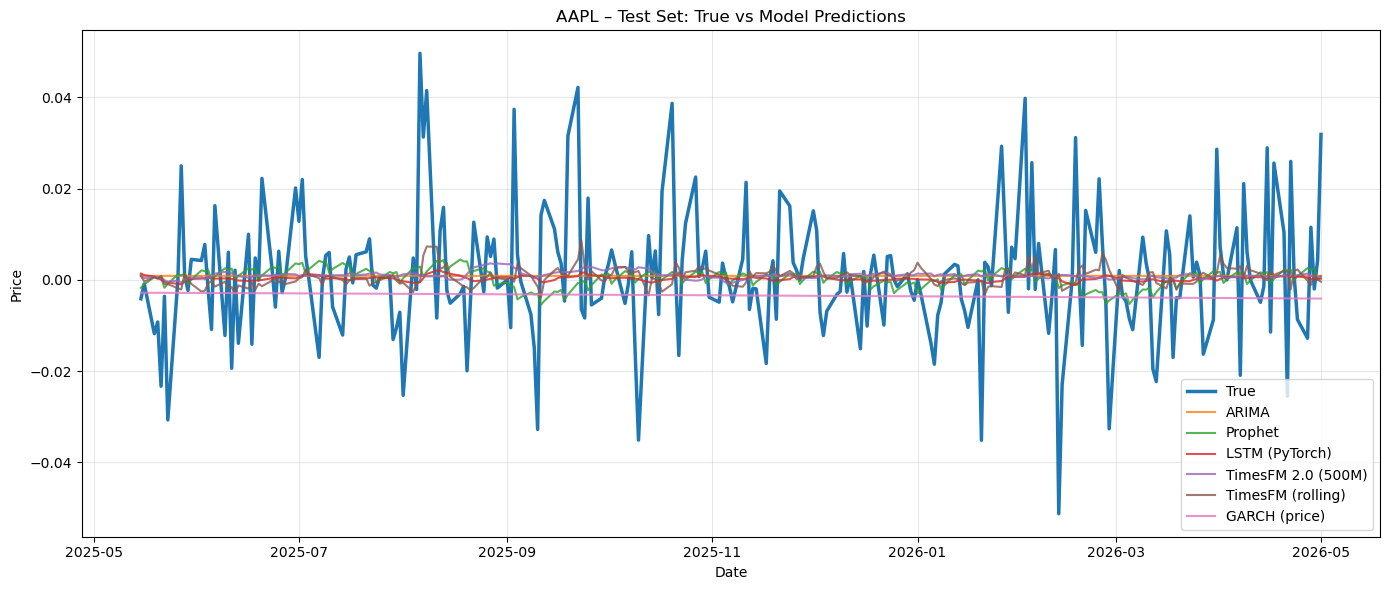

In [120]:
import matplotlib.pyplot as plt
pred_df = pd.concat(
    {
        'True':                test[TICKER],
        'ARIMA':               arima_pred,
        'Prophet':             prophet_pred,
        'LSTM (PyTorch)':      lstm_pred,
        'TimesFM 2.0 (500M)':  timesfm_pred,      # optional, comment out if not used
        'TimesFM (rolling)':   timesfm_roll_expand,
        'GARCH (price)':       garch_price_pred,
    },
    axis=1
)

# Make sure everything lines up and drop rows where any model is missing
#pred_df = pred_df.dropna(how='any')
#N = len(pred_df)
#plot_df = pred_df.iloc[-N:]
plot_df = pred_df

plt.figure(figsize=(14, 6))

for col in plot_df.columns:
    if col == 'True':
        plt.plot(plot_df.index, plot_df[col], label=col, linewidth=2.5)
    else:
        plt.plot(plot_df.index, plot_df[col], label=col, alpha=0.8)

plt.title(f"{TICKER} – Test Set: True vs Model Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [122]:
import pandas as pd
import numpy as np

def calculate_directional_accuracy(df, true_col):
    # Calculate the actual movement direction (1 for up, -1 for down, 0 for flat)
    # We compare today's price to yesterday's price
    actual_dir = np.sign(df[true_col].diff())
    
    results = {}
    
    # Iterate through all prediction columns in your pred_df
    for col in df.columns:
        if col == true_col:
            continue
            
        # Calculate predicted direction
        # IMPORTANT: For one-step-ahead rolling models, compare pred_t+1 to actual_t
        # For multi-step (Purple line), compare pred_t+1 to pred_t
        pred_dir = np.sign(df[col].diff())
        
        # Accuracy is the percentage of times the signs match
        # We drop the first row because diff() results in NaN
        matches = (actual_dir == pred_dir).dropna()
        accuracy = matches.mean() * 100
        
        results[col] = f"{accuracy:.2f}%"
        
    return results

# Apply to your specific dataframe
hit_rates = calculate_directional_accuracy(pred_df, 'True')

# Display as a clean table
print("Directional Accuracy (Hit Rate):")
for model, rate in hit_rates.items():
    print(f"{model:20} : {rate}")

Directional Accuracy (Hit Rate):
ARIMA                : 0.79%
Prophet              : 53.57%
LSTM (PyTorch)       : 35.71%
TimesFM 2.0 (500M)   : 45.63%
TimesFM (rolling)    : 36.11%
GARCH (price)        : 52.38%
